In [6]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# 加载数据（假设数据文件名为 train.csv 和 test.csv）
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# 使用 RandomForestRegressor 填补缺失的年龄属性
def set_missing_ages(df):
    # 把已有的数值型特征取出来丢进Random Forest Regressor中
    age_df = df[['Age', 'Fare', 'Parch', 'SibSp', 'Pclass']]

    # 乘客分成已知年龄和未知年龄两部分
    known_age = age_df[age_df.Age.notnull()].values
    unknown_age = age_df[age_df.Age.isnull()].values

    # y即目标年龄
    y = known_age[:, 0]

    # X即特征属性值
    X = known_age[:, 1:]

    # fit到RandomForestRegressor之中
    rfr = RandomForestRegressor(random_state=0, n_estimators=2000, n_jobs=-1)
    rfr.fit(X, y)

    # 用得到的模型进行未知年龄结果预测
    predictedAges = rfr.predict(unknown_age[:, 1::])

    # 用得到的预测结果填补原缺失数据
    df.loc[df.Age.isnull(), 'Age'] = predictedAges

    return df, rfr
    
# 数据预处理函数
def preprocess_data(data, is_train=True):
    # 1. 删除无用列
    drop_cols = ["Ticket", "Cabin"]
    if is_train:
        drop_cols.append("PassengerId")
    data = data.drop(drop_cols, axis=1)
    
    # 2. 处理缺失值
    data, _ = set_missing_ages(data)  # 使用 RandomForestRegressor 填补缺失的年龄属性
    data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])
    data["Fare"] = data["Fare"].fillna(data["Fare"].median())
    
    # 3. 特征工程
    # FamilySize & IsAlone
    data["FamilySize"] = data["SibSp"] + data["Parch"] + 1
    data["IsAlone"] = (data["FamilySize"] == 1).astype(int)
    
    # Title处理
    data["Title"] = data["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)
    title_mapping = {
        'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
        'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
        'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare',
        'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'
    }
    data["Title"] = data["Title"].replace(title_mapping)
    
    # AgeBand分段（直接覆盖Age列，无需保留原始Age）
    data["AgeBand"] = pd.cut(data["Age"], bins=[0, 12, 18, 30, 50, 100], 
                            labels=['Child','Teenager','YoungAdult','Adult','Senior'])
    data = data.drop(["Name","Age"], axis=1)
    
    return data

# 应用数据预处理
train = preprocess_data(train, is_train=True)
test = preprocess_data(test, is_train=False)

基础模型准确率: 0.7933
基础模型精确率: 0.7581
基础模型召回率: 0.6812
基础模型F1分数: 0.7176
分类报告:
               precision    recall  f1-score   support

           0       0.81      0.86      0.84       110
           1       0.76      0.68      0.72        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



In [11]:
train.head()

,Survived,Pclass,Sex,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,AgeBand
0,0,3,male,1,0,7.2500,S,2,0,Mr,YoungAdult
1,1,1,female,1,0,71.2833,C,2,0,Mrs,Adult
2,1,3,female,0,0,7.9250,S,1,1,Miss,YoungAdult
3,1,1,female,1,0,53.1000,S,2,0,Mrs,Adult
4,0,3,male,0,0,8.0500,S,1,1,Mr,Adult


In [12]:
# ====================
# 数据编码
# ====================
# 分类变量编码
categorical_features = ['Sex', 'Embarked', 'Title', 'AgeBand']
numerical_features = ['Pclass', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']

# 使用ColumnTransformer和Pipeline进行编码
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# ====================
# 划分数据集
# ====================
X = train.drop('Survived', axis=1)
y = train['Survived']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ====================
# XGBoost模型训练
# ====================
# 创建管道
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

# 训练模型
pipeline.fit(X_train, y_train)

# 验证集预测
y_pred = pipeline.predict(X_val)
print(f"基础模型准确率: {accuracy_score(y_val, y_pred):.4f}")
print(f"基础模型精确率: {precision_score(y_val, y_pred):.4f}")
print(f"基础模型召回率: {recall_score(y_val, y_pred):.4f}")
print(f"基础模型F1分数: {f1_score(y_val, y_pred):.4f}")
print("分类报告:\n", classification_report(y_val, y_pred))

基础模型准确率: 0.7933
基础模型精确率: 0.7581
基础模型召回率: 0.6812
基础模型F1分数: 0.7176
分类报告:
               precision    recall  f1-score   support

           0       0.81      0.86      0.84       110
           1       0.76      0.68      0.72        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



In [13]:
# ====================
# 超参数调优（示例）
# ====================
param_grid = {
    'classifier__max_depth': [3, 4, 5],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.7, 0.8, 0.9],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9]
}

# 使用StratifiedKFold进行分层交叉验证
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 网格搜索
grid = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring='accuracy')
grid.fit(X_train, y_train)
print("最优参数:", grid.best_params_)

# 使用最优参数的模型进行预测
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_val)
print(f"最优模型准确率: {accuracy_score(y_val, y_pred_best):.4f}")
print(f"最优模型精确率: {precision_score(y_val, y_pred_best):.4f}")
print(f"最优模型召回率: {recall_score(y_val, y_pred_best):.4f}")
print(f"最优模型F1分数: {f1_score(y_val, y_pred_best):.4f}")
print("最优模型分类报告:\n", classification_report(y_val, y_pred_best))

最优参数: {'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__subsample': 0.9}
最优模型准确率: 0.8156
最优模型精确率: 0.8000
最优模型召回率: 0.6957
最优模型F1分数: 0.7442
最优模型分类报告:
               precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



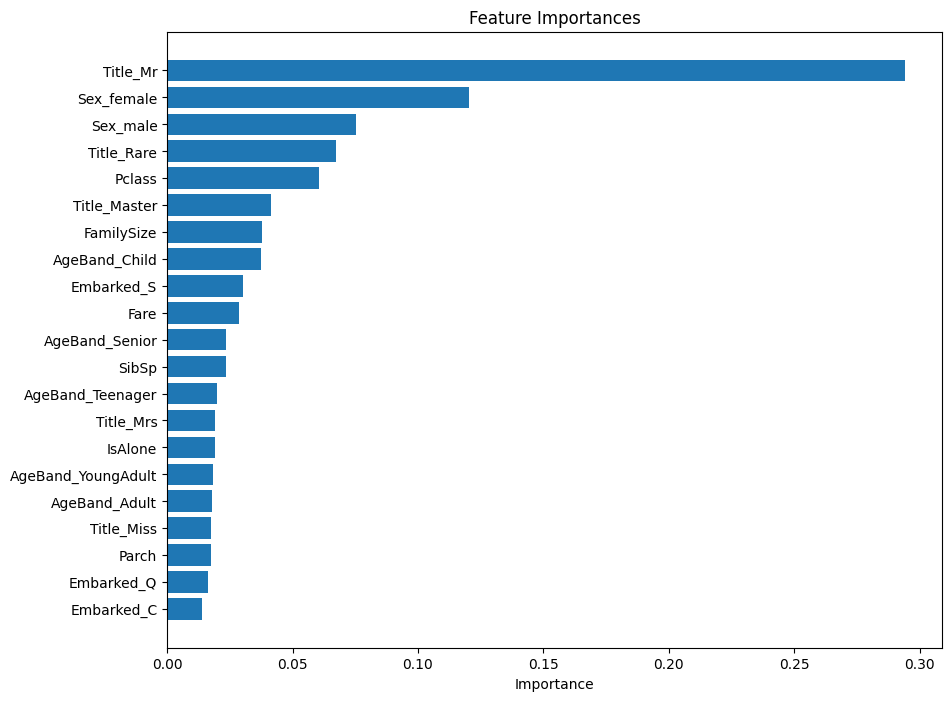

In [14]:
# ====================
# 特征重要性可视化
# ====================
# 获取特征名称
feature_names = numerical_features + list(pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features))

# 获取特征重要性
feature_importances = pipeline.named_steps['classifier'].feature_importances_

# 创建特征重要性DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# 可视化特征重要性
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importances')
plt.gca().invert_yaxis()  # 将最重要的特征放在顶部
plt.show()

In [14]:
# ====================
# 测试集预测
# ====================
# 对测试集进行预测
test_predictions = best_model.predict(test)

# 保存预测结果
submission = pd.DataFrame({
    'PassengerId': pd.read_csv('test.csv')['PassengerId'],
    'Survived': test_predictions
})
submission.to_csv('titanic_submission.csv', index=False)
print("测试集预测结果已保存到 titanic_submission.csv 文件中。")

测试集预测结果已保存到 titanic_submission.csv 文件中。
